## 2B.Network Depth Comparison

In [64]:
from tensorflow.keras import layers, models
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import src.utils as utils
importlib.reload(utils)

from src.utils import load_and_split_data
from src.utils import train_and_evaluate
from src.utils import BaselineCNN
from src.utils import run_Experiment_C



In [ ]:
#Shallow (4 conv layers):
def build_shallow():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
#Medium (6 conv layers):
def build_medium():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
#Deep (8 conv layers):
def build_deep():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [68]:
models_list = [
    ("Shallow", build_shallow()),
    ("Medium", build_medium()),
    ("Deep", build_deep())
]

histories = []
results = []

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#excecute training and evaluation for each model
for name, model in models_list:
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"\nTraining {name} model...")

    history, acc, loss, t = train_and_evaluate(
        model,
        x_train_C, y_train,
        x_val_C, y_val,
        x_test_C, y_test
    )

    histories.append((name, history))
    results.append((name, acc, loss, t))


Training Shallow model...
Test Acc: 0.6798 | Test Loss: 2.5063 | Time:1362.9s

Training Medium model...
Test Acc: 0.7408 | Test Loss: 0.7494 | Time:1636.6s

Training Deep model...
Test Acc: 0.7116 | Test Loss: 1.0061 | Time:1774.1s


In [ ]:
#display results
df = pd.DataFrame(results, columns=["Model", "Accuracy", "Loss", "Time"])
df

,Model,Accuracy,Loss,Time
0,Shallow,0.6798,2.506263,1362.850164
1,Medium,0.7408,0.749436,1636.573088
2,Deep,0.7116,1.006145,1774.080718


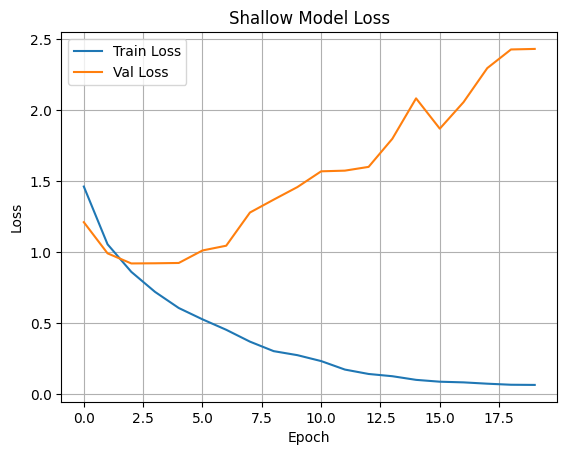

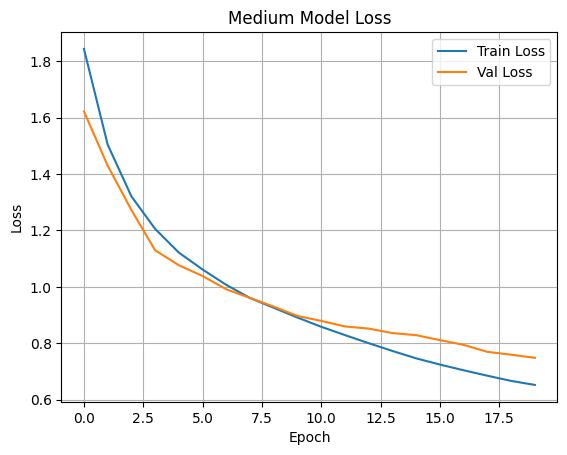

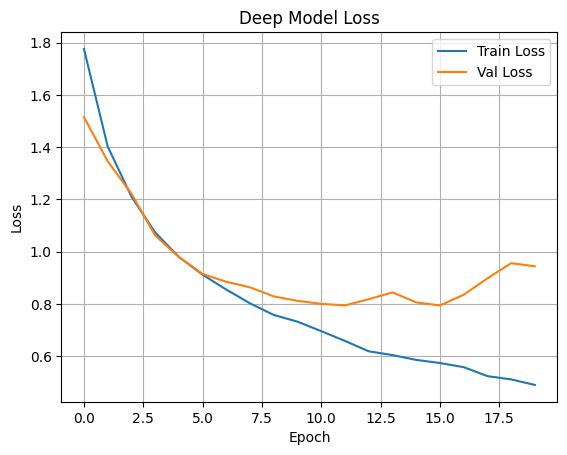

In [ ]:
#plot training and validation loss curves
for name, history in histories:
    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{name} Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()